# Model Validation and Cross-Validation Strategies

## Cross-Validation as a Statistical Estimator 

### Review: $k$-Fold Cross-Validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold,
    cross_val_score, cross_validate,
    GridSearchCV, GroupKFold, TimeSeriesSplit
)
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ── Re-create datasets and pipelines from Chapter 14 ─────────────────────
import pandas as pd

adult_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/adult/adult.data"
)
adult_cols = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]
df_adult = pd.read_csv(adult_url, names=adult_cols,
                       na_values=" ?", skipinitialspace=True)
df_adult["income"] = (df_adult["income"].str.strip() == ">50K").astype(int)
df_adult = df_adult.dropna()

cat_cols_adult = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]
num_cols_adult = [
    "age", "fnlwgt", "education_num", "capital_gain",
    "capital_loss", "hours_per_week"
]

X_adult = df_adult[num_cols_adult + cat_cols_adult]
y_adult = df_adult["income"]

X_atr, X_ate, y_atr, y_ate = train_test_split(
    X_adult, y_adult,
    test_size=0.20, stratify=y_adult, random_state=RANDOM_SEED
)

def adult_preprocessor():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols_adult),
        ("cat", cat_pipe, cat_cols_adult)
    ])

def make_adult_pipe(clf):
    return Pipeline([
        ("preprocessor", adult_preprocessor()),
        ("clf",           clf)
    ])

### Comparing k Values: Bias and Variance

In [2]:
# ── CV stability across k values ─────────────────────────────────────────
pipe_lr = make_adult_pipe(
    LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)
)

print(f"{'k':>4}  {'Mean AUC':>10}  {'Std AUC':>10}  {'N folds':>8}")
print("-" * 38)

for k in [3, 5, 10, 20]:
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
    scores = cross_val_score(
        pipe_lr, X_atr, y_atr, cv=kf, scoring="roc_auc", n_jobs=-1
    )
    print(f"{k:>4}  {scores.mean():>10.4f}  {scores.std():>10.4f}  {k:>8}")

   k    Mean AUC     Std AUC   N folds
--------------------------------------
   3      0.8524      0.0025         3
   5      0.8521      0.0046         5
  10      0.8522      0.0057        10
  20      0.8521      0.0099        20


## Nested Cross-Validation

### The Optimism Bias Problem

In [3]:
# ── Non-nested CV: GridSearchCV reports its own best score ────────────────
param_grid = {
    "clf__max_depth":     [3, 4, 5],
    "clf__learning_rate": [0.05, 0.1, 0.2],
    "clf__n_estimators":  [100, 200],
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED + 1)

gs_simple = GridSearchCV(
    make_adult_pipe(
        GradientBoostingClassifier(subsample=0.8, random_state=RANDOM_SEED)
    ),
    param_grid, cv=inner_cv, scoring="roc_auc",
    n_jobs=-1, refit=True
)
gs_simple.fit(X_atr, y_atr)
simple_cv_score = gs_simple.best_score_

# ── Nested CV: outer loop evaluates after inner-loop selection ────────────
gs_nested = GridSearchCV(
    make_adult_pipe(
        GradientBoostingClassifier(subsample=0.8, random_state=RANDOM_SEED)
    ),
    param_grid, cv=inner_cv, scoring="roc_auc",
    n_jobs=-1, refit=True
)
nested_scores = cross_val_score(
    gs_nested, X_atr, y_atr,
    cv=outer_cv, scoring="roc_auc", n_jobs=-1
)

print("Cross-Validation Comparison")
print(f"  Non-nested CV best score   : {simple_cv_score:.4f}  "
      f"(optimistic — selected as max over grid)")
print(f"  Nested CV mean score       : {nested_scores.mean():.4f}  ±  "
      f"{nested_scores.std():.4f}")
print(f"  Optimism bias              : "
      f"{simple_cv_score - nested_scores.mean():+.4f}")

Cross-Validation Comparison
  Non-nested CV best score   : 0.9260  (optimistic — selected as max over grid)
  Nested CV mean score       : 0.9259  ±  0.0061
  Optimism bias              : +0.0001


### Visualising the Nested CV Structure

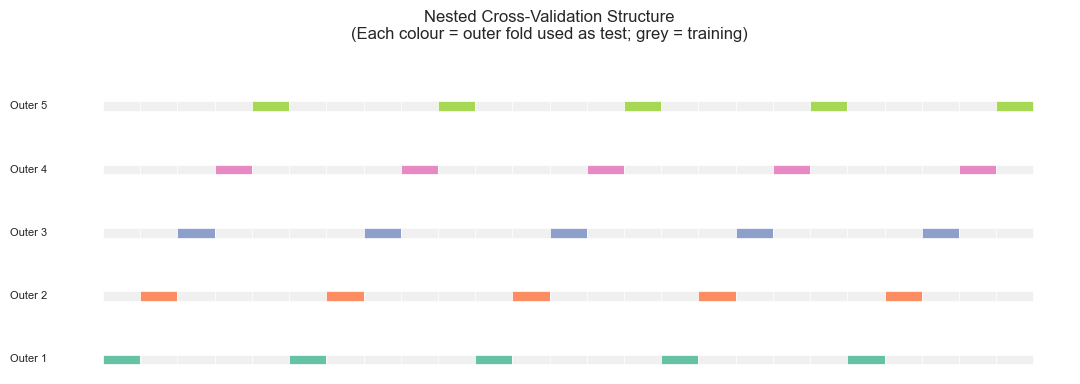

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))

n_outer, n_inner = 5, 5
n_total = 25  # schematic: 25 "blocks"

cmap_outer = plt.cm.Set2.colors
cmap_inner = ["#d0eaff", "#ffe0b0"]

for outer_fold in range(n_outer):
    # outer test block
    for j in range(n_total):
        fold_id = j % n_outer
        color = cmap_outer[outer_fold] if fold_id == outer_fold else "#f0f0f0"
        rect = plt.Rectangle([j, outer_fold * (n_inner + 1.5)],
                              1, 1, color=color, ec="white", lw=0.5)
        ax.add_patch(rect)
    ax.text(-1.5, outer_fold * (n_inner + 1.5) + 0.5,
            f"Outer {outer_fold+1}", va="center", ha="right", fontsize=8)

ax.set_xlim(-2, n_total + 1)
ax.set_ylim(-1, n_outer * (n_inner + 1.5))
ax.axis("off")
ax.set_title("Nested Cross-Validation Structure\n"
             "(Each colour = outer fold used as test; grey = training)")
plt.tight_layout()
plt.savefig(FIGURES / "ch15_nested_cv_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

## Stratified, Group, and Time-Series CV Protocols

In [5]:
kf_std   = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
kf_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print("Positive rate per fold — Standard KFold vs. Stratified KFold")
print(f"{'Fold':>4}  {'Standard':>10}  {'Stratified':>12}")
print("-" * 32)

for fold_idx, ((_, vi), (_, vs)) in enumerate(
    zip(kf_std.split(X_atr, y_atr), kf_strat.split(X_atr, y_atr)), 1
):
    rate_std   = y_atr.iloc[vi].mean()
    rate_strat = y_atr.iloc[vs].mean()
    print(f"   {fold_idx}   {rate_std:10.4f}  {rate_strat:12.4f}")

print(f"\nOverall positive rate: {y_atr.mean():.4f}")

Positive rate per fold — Standard KFold vs. Stratified KFold
Fold    Standard    Stratified
--------------------------------
   1       0.2484        0.2409
   2       0.2401        0.2409
   3       0.2405        0.2409
   4       0.2309        0.2407
   5       0.2442        0.2407

Overall positive rate: 0.2408


### Group K-Fold

In [6]:
# ── Simulated grouped dataset: 500 patients, 6 visits each ───────────────
n_patients, n_visits = 500, 6
n_obs = n_patients * n_visits

X_grouped = pd.DataFrame({
    "feature_1": np.random.normal(0, 1, n_obs),
    "feature_2": np.random.normal(0, 1, n_obs),
})
y_grouped  = np.random.randint(0, 2, n_obs)
groups     = np.repeat(np.arange(n_patients), n_visits)

gkf = GroupKFold(n_splits=5)

print("GroupKFold: verifying no patient appears in both train and val")
for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X_grouped, y_grouped, groups), 1
):
    train_groups = set(groups[train_idx])
    val_groups   = set(groups[val_idx])
    overlap = train_groups & val_groups
    print(f"  Fold {fold}: train groups={len(train_groups):3d}  "
          f"val groups={len(val_groups):3d}  overlap={len(overlap)}")

GroupKFold: verifying no patient appears in both train and val
  Fold 1: train groups=400  val groups=100  overlap=0
  Fold 2: train groups=400  val groups=100  overlap=0
  Fold 3: train groups=400  val groups=100  overlap=0
  Fold 4: train groups=400  val groups=100  overlap=0
  Fold 5: train groups=400  val groups=100  overlap=0


### Time-Series Split

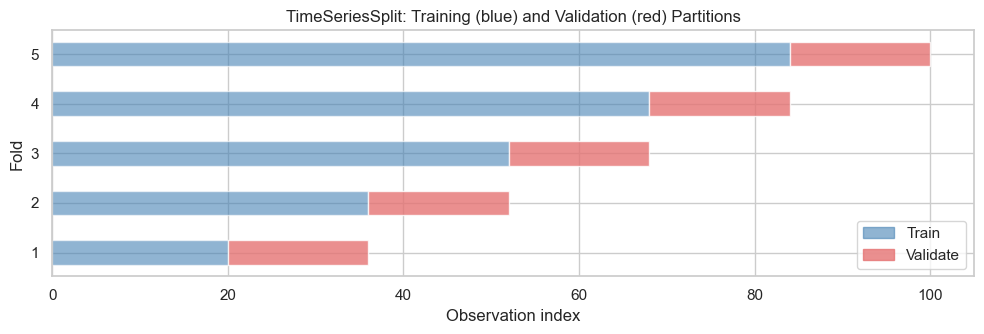

In [7]:
# ── Schematic of TimeSeriesSplit structure ────────────────────────────────
tss = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(10, 3.5))
n_samples = 100

for fold_idx, (train_idx, val_idx) in enumerate(
    tss.split(np.arange(n_samples)), 1
):
    ax.barh(fold_idx, len(train_idx), left=0,
            color="steelblue", alpha=0.6, height=0.5)
    ax.barh(fold_idx, len(val_idx), left=len(train_idx),
            color="#E57373", alpha=0.8, height=0.5)

ax.set_xlabel("Observation index")
ax.set_ylabel("Fold")
ax.set_title("TimeSeriesSplit: Training (blue) and Validation (red) Partitions")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue", alpha=0.6, label="Train"),
    Patch(color="#E57373",   alpha=0.8, label="Validate"),
], loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "ch15_tss_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

## Cross-Validation Pitfalls and Best Practices 

### Pitfall 1: Preprocessing Outside the Pipeline

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as LR
from sklearn.metrics import roc_auc_score

# ── WRONG: scale before CV ────────────────────────────────────────────────
# (shown for illustration — do not do this)
X_atr_array = X_atr[num_cols_adult].values

scaler_leaky = StandardScaler()
X_scaled_leaky = scaler_leaky.fit_transform(X_atr_array)   # leakage!

scores_leaky = cross_val_score(
    LR(max_iter=1000), X_scaled_leaky, y_atr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc"
)

# ── CORRECT: scale inside pipeline ───────────────────────────────────────
pipe_correct = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LR(max_iter=1000))
])
scores_correct = cross_val_score(
    pipe_correct, X_atr_array, y_atr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc"
)

print("Leaky CV (scale before split): "
      f"{scores_leaky.mean():.4f} ± {scores_leaky.std():.4f}")
print("Correct CV (scale in pipeline): "
      f"{scores_correct.mean():.4f} ± {scores_correct.std():.4f}")
print(f"Optimism from leakage: {scores_leaky.mean() - scores_correct.mean():+.4f}")

Leaky CV (scale before split): 0.8300 ± 0.0083
Correct CV (scale in pipeline): 0.8300 ± 0.0083
Optimism from leakage: +0.0000


### Cross-Validation Best Practices Summary

In [9]:
print("Cross-Validation Best Practices")
print("-" * 50)

best_practices = {
    "Always use pipelines":
        "Fit ALL preprocessing (scalers, imputers, encoders, "
        "feature selectors) inside a Pipeline. Never on the full dataset.",
    "Match protocol to data structure":
        "StratifiedKFold for classification; GroupKFold for grouped "
        "data; TimeSeriesSplit for temporal data.",
    "Use nested CV for model selection":
        "If tuning hyperparameters AND reporting performance, use "
        "nested CV to separate the two concerns.",
    "Report mean ± std of fold scores":
        "A single CV mean without variance information is misleading. "
        "Report both, especially for small datasets.",
    "k=10 for final evaluations":
        "k=5 is acceptable for exploratory work; k=10 for reported results.",
    "Never use test set during CV":
        "The test set must not influence any model or preprocessing decision. "
        "CV operates entirely within the training partition.",
}

for practice, description in best_practices.items():
    print(f"\n  ✓ {practice}")
    print(f"    → {description}")

Cross-Validation Best Practices
--------------------------------------------------

  ✓ Always use pipelines
    → Fit ALL preprocessing (scalers, imputers, encoders, feature selectors) inside a Pipeline. Never on the full dataset.

  ✓ Match protocol to data structure
    → StratifiedKFold for classification; GroupKFold for grouped data; TimeSeriesSplit for temporal data.

  ✓ Use nested CV for model selection
    → If tuning hyperparameters AND reporting performance, use nested CV to separate the two concerns.

  ✓ Report mean ± std of fold scores
    → A single CV mean without variance information is misleading. Report both, especially for small datasets.

  ✓ k=10 for final evaluations
    → k=5 is acceptable for exploratory work; k=10 for reported results.

  ✓ Never use test set during CV
    → The test set must not influence any model or preprocessing decision. CV operates entirely within the training partition.
